# Contexto

## Importacion de librerias

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as norm

## Cargo el archivo ventasTransformed.csv

In [61]:
df = pd.read_csv('ventasTransformed.csv', encoding="latin-1")
df.head()

,VentaID,Anio,Trimestre,Mes,Dia,HoraVenta,SucursalNombre,CiudadSucursal,VendedorNombre,ClienteNombre,...,CantidadProducto2,PrecioUnitarioProducto2,SubtotalProducto2,NombreProducto3,MarcaProducto3,CantidadProducto3,PrecioUnitarioProducto3,SubtotalProducto3,DescuentoVenta,TotalVenta
0,1,2015,Qtr 4,diciembre,31,1899-12-30 05:42:43,Techcore Pereira,Pereira,Amílcar Ortega-Alberto,Bienvenida Nebot-Fiol,...,2,"$8,000,000.00","$16,000,000.00",Dell Latitude 7420,Dell,1,"$5,600,000.00","$5,600,000.00",0.00%,"$31,200,000.00"
1,2,2019,Qtr 1,marzo,23,1899-12-30 19:03:21,Techcore Medellín #1,Medellín,Ana Sofía Llopis Blázquez,Teófila Bueno-Novoa,...,1,"$6,800,000.00","$6,800,000.00",NaN,NaN,0,NaN,NaN,0.00%,"$10,800,000.00"
2,3,2018,Qtr 4,diciembre,23,1899-12-30 02:32:34,Techcore Medellín #2,Medellín,Juan José Porcel-Riera,Gilberto Chamorro Catalá,...,1,"$7,200,000.00","$7,200,000.00",HP Pavilion 15,HP,1,"$3,500,000.00","$3,500,000.00",0.00%,"$21,900,000.00"
3,4,2015,Qtr 4,noviembre,14,1899-12-30 00:37:36,Techcore Medellín #2,Medellín,Juan José Porcel-Riera,Máximo Coronado Huerta,...,2,"$4,400,000.00","$8,800,000.00",NaN,NaN,0,NaN,NaN,0.00%,"$13,600,000.00"
4,5,2016,Qtr 4,noviembre,29,1899-12-30 10:34:20,Techcore Cali,Cali,Jacinta Juárez Marín,Yago Oliver,...,1,"$3,500,000.00","$3,500,000.00",Microsoft Surface Laptop 4,Microsoft,1,"$5,200,000.00","$5,200,000.00",0.00%,"$13,900,000.00"


## Columnas

In [62]:
df.columns

Index(['VentaID', 'Anio', 'Trimestre', 'Mes', 'Dia', 'HoraVenta',
       'SucursalNombre', 'CiudadSucursal', 'VendedorNombre', 'ClienteNombre',
       'GeneroCliente', 'EdadCliente', 'EmailCliente', 'TelefonoCliente',
       'DireccionCliente', 'MetodoPago', 'NombreProducto1', 'MarcaProducto1',
       'CantidadProducto1', 'PrecioUnitarioProducto1', 'SubtotalProducto1',
       'NombreProducto2', 'MarcaProducto2', 'CantidadProducto2',
       'PrecioUnitarioProducto2', 'SubtotalProducto2', 'NombreProducto3',
       'MarcaProducto3', 'CantidadProducto3', 'PrecioUnitarioProducto3',
       'SubtotalProducto3', 'DescuentoVenta', 'TotalVenta'],
      dtype='object')

### Tabla de ciudades

In [63]:
ciudades = df['CiudadSucursal'].unique()
ciudades = pd.DataFrame(ciudades, columns=['Ciudad'])
ciudades['CiudadID'] = ciudades.index + 1
ciudades = ciudades[['CiudadID', 'Ciudad']]
ciudades

,CiudadID,Ciudad
0,1,Pereira
1,2,Medellín
2,3,Cali
3,4,Bogotá


### Tabla de sucursales

In [64]:
sucursales = df[['SucursalNombre', 'CiudadSucursal']].drop_duplicates().reset_index(drop=True)
sucursales['SucursalID'] = sucursales.index + 1
sucursales = sucursales.merge(
    ciudades,
    left_on='CiudadSucursal',
    right_on='Ciudad',
    how='left'
)
sucursales = sucursales[['SucursalID', 'SucursalNombre', 'CiudadID']]

sucursales


,SucursalID,SucursalNombre,CiudadID
0,1,Techcore Pereira,1
1,2,Techcore Medellín #1,2
2,3,Techcore Medellín #2,2
3,4,Techcore Cali,3
4,5,Techcore Bogotá #2,4
5,6,Techcore Bogotá #1,4


### Tabla de productos

In [65]:
# Uno los productos de las 3 columnas en una sola tabla
p1 = df[['NombreProducto1', 'MarcaProducto1']].rename(
    columns={'NombreProducto1': 'NombreProducto', 'MarcaProducto1': 'MarcaProducto'}
)
p2 = df[['NombreProducto2', 'MarcaProducto2']].rename(
    columns={'NombreProducto2': 'NombreProducto', 'MarcaProducto2': 'MarcaProducto'}
)
p3 = df[['NombreProducto3', 'MarcaProducto3']].rename(
    columns={'NombreProducto3': 'NombreProducto', 'MarcaProducto3': 'MarcaProducto'}
)

productos = pd.concat([p1, p2, p3], ignore_index=True)

# elimino filas vacías y duplicadas
productos = productos.dropna(subset=['NombreProducto']).copy()
productos['NombreProducto'] = productos['NombreProducto'].astype(str).str.strip()
productos['MarcaProducto'] = productos['MarcaProducto'].astype(str).str.strip()

productos = productos.drop_duplicates().reset_index(drop=True)

# Creo ID
productos['ProductoID'] = productos.index + 1

# Orden final
productos = productos[['ProductoID', 'NombreProducto', 'MarcaProducto']]

productos


,ProductoID,NombreProducto,MarcaProducto
0,1,Apple MacBook Pro 16,Apple
1,2,Acer Nitro 5,Acer
2,3,Dell Latitude 7420,Dell
3,4,Asus TUF Gaming A15,Asus
4,5,HP Spectre x360,HP
5,6,Samsung Galaxy Book Odyssey,Samsung
6,7,Lenovo IdeaPad 5,Lenovo
7,8,Dell XPS 13,Dell
8,9,Lenovo Legion 5 Pro,Lenovo
9,10,HP Pavilion 15,HP


### Tabla de clientes

In [66]:
clientes = (
    df[[
        'ClienteNombre',
        'GeneroCliente',
        'EdadCliente',
        'EmailCliente',
        'TelefonoCliente',
        'DireccionCliente'
    ]]
    .drop_duplicates()
    .reset_index(drop=True)
)

clientes['ClienteID'] = clientes.index + 1

clientes = clientes[[
    'ClienteID',
    'ClienteNombre',
    'GeneroCliente',
    'EdadCliente',
    'EmailCliente',
    'TelefonoCliente',
    'DireccionCliente'
]]

clientes


,ClienteID,ClienteNombre,GeneroCliente,EdadCliente,EmailCliente,TelefonoCliente,DireccionCliente
0,1,Bienvenida Nebot-Fiol,F,37,bienvenida19@hotmail.com,'+34806548767,cll 52 #32-98
1,2,Teófila Bueno-Novoa,F,43,Teófila35@gmail.com,'+34 947255990,cll 96 #81-94
2,3,Gilberto Chamorro Catalá,M,38,gilberto57@hotmail.com,'+34 978 810 249,cra 28 #79-85
3,4,Máximo Coronado Huerta,M,30,Máximo65@hotmail.com,'+34 825429634,cll 5 #89-26
4,5,Yago Oliver,M,51,yago38@yahoo.com,'+34988285275,cra 32 #97-86
...,...,...,...,...,...,...,...
17502,17503,Jose Miguel Rosa Arenas,M,26,jose32@yahoo.com,'+34 744 79 73 83,cll 32 #35-85
17503,17504,Manolo Lerma,M,41,manolo78@hotmail.com,'+34 627546892,cll 27 #59-20
17504,17505,Ildefonso Abad Amigó,M,26,ildefonso41@yahoo.com,'+34 977633270,cra 14 #68-3
17505,17506,Gabriel Cristian Zamora Artigas,M,50,NaN,'+34885 996 094,cll 46 #62-87


### Tabla de vendedores

In [67]:
vendedores = df['VendedorNombre'].unique()
vendedores = pd.DataFrame(vendedores, columns=['Vendedor'])
vendedores['VendedorID'] = vendedores.index + 1
vendedores = vendedores[['VendedorID', 'Vendedor']]
vendedores

,VendedorID,Vendedor
0,1,Amílcar Ortega-Alberto
1,2,Ana Sofía Llopis Blázquez
2,3,Juan José Porcel-Riera
3,4,Jacinta Juárez Marín
4,5,Clímaco Salinas Zabaleta
5,6,Carina Parejo Carranza
6,7,Edu Juan Pedraza
7,8,Armida Azorin Plaza
8,9,Rosendo Barberá Cordero
9,10,Herminia Meléndez-Huguet


### Tabla de facturas

In [68]:

# 1) Crear una tabla base de facturas (cabecera)
facturas_base = (
    df[[
        'VentaID',
        'Anio', 
        'Mes', 
        'Dia',
        'HoraVenta', 
        'MetodoPago',
        'DescuentoVenta',
        'TotalVenta',
        'ClienteNombre', 
        'GeneroCliente', 
        'EdadCliente', 
        'EmailCliente', 
        'TelefonoCliente', 
        'DireccionCliente',
        'VendedorNombre',
        'SucursalNombre', 
        'CiudadSucursal'
    ]]
    .drop_duplicates(subset=['VentaID'])  # 1 factura por VentaID
    .reset_index(drop=True)
)

# ClienteID (merge con la tabla clientes)
facturas = facturas_base.merge(
    clientes,
    on=['ClienteNombre','GeneroCliente','EdadCliente','EmailCliente','TelefonoCliente','DireccionCliente'],
    how='left',
    validate='many_to_one'
)

# VendedorID
facturas = facturas.merge(
    vendedores,
    left_on='VendedorNombre',
    right_on='Vendedor',
    how='left',
    validate='many_to_one'
)

# SucursalID 
# Primero mapear CiudadID en facturas
facturas = facturas.merge(
    ciudades,
    left_on='CiudadSucursal',
    right_on='Ciudad',
    how='left',
    validate='many_to_one'
)

# Luego mapear SucursalID usando (SucursalNombre, CiudadID)
facturas = facturas.merge(
    sucursales[['SucursalID','SucursalNombre','CiudadID']],
    on=['SucursalNombre','CiudadID'],
    how='left',
    validate='many_to_one'
)

# Selección final de columnas
facturas = facturas.rename(columns={'VentaID': 'FacturaID'})

facturas = facturas[[
    'FacturaID',
    'Dia',
    'Mes',
    'Anio',
    'HoraVenta',
    'MetodoPago',
    'SucursalID',
    'VendedorID',
    'ClienteID',
    'DescuentoVenta',
    'TotalVenta'
]].drop_duplicates().reset_index(drop=True)

facturas.head(10)


,FacturaID,Dia,Mes,Anio,HoraVenta,MetodoPago,SucursalID,VendedorID,ClienteID,DescuentoVenta,TotalVenta
0,1,31,diciembre,2015,1899-12-30 05:42:43,Tarjeta Crédito,1,1,1,0.00%,"$31,200,000.00"
1,2,23,marzo,2019,1899-12-30 19:03:21,Billetera Digital,2,2,2,0.00%,"$10,800,000.00"
2,3,23,diciembre,2018,1899-12-30 02:32:34,Tarjeta Débito,3,3,3,0.00%,"$21,900,000.00"
3,4,14,noviembre,2015,1899-12-30 00:37:36,Billetera Digital,3,3,4,0.00%,"$13,600,000.00"
4,5,29,noviembre,2016,1899-12-30 10:34:20,Tarjeta Crédito,4,4,5,0.00%,"$13,900,000.00"
5,6,8,enero,2015,1899-12-30 22:33:55,Billetera Digital,4,5,6,0.00%,"$17,600,000.00"
6,7,2,octubre,2022,1899-12-30 11:56:06,Billetera Digital,4,4,7,15.00%,"$12,920,000.00"
7,8,4,junio,2022,1899-12-30 07:00:48,Tarjeta Crédito,1,6,8,5.00%,"$23,940,000.00"
8,9,14,enero,2019,1899-12-30 12:27:53,Tarjeta Crédito,5,7,9,0.00%,"$4,800,000.00"
9,10,19,julio,2023,1899-12-30 14:25:30,Transferencia,5,8,10,0.00%,"$28,000,000.00"


### Tabla de detalles

In [69]:
# 3 dataframes de productos ID y los concatenamos
d1 = df[['VentaID','NombreProducto1','MarcaProducto1','CantidadProducto1','PrecioUnitarioProducto1','SubtotalProducto1']].copy()
d1 = d1.rename(columns={
    'VentaID':'FacturaID',
    'NombreProducto1':'NombreProducto',
    'MarcaProducto1':'MarcaProducto',
    'CantidadProducto1':'Cantidad',
    'PrecioUnitarioProducto1':'PrecioUnitario',
    'SubtotalProducto1':'Subtotal'
})
d1['ProductoNro'] = 1

d2 = df[['VentaID','NombreProducto2','MarcaProducto2','CantidadProducto2','PrecioUnitarioProducto2','SubtotalProducto2']].copy()
d2 = d2.rename(columns={
    'VentaID':'FacturaID',
    'NombreProducto2':'NombreProducto',
    'MarcaProducto2':'MarcaProducto',
    'CantidadProducto2':'Cantidad',
    'PrecioUnitarioProducto2':'PrecioUnitario',
    'SubtotalProducto2':'Subtotal'
})
d2['ProductoNro'] = 2

d3 = df[['VentaID','NombreProducto3','MarcaProducto3','CantidadProducto3','PrecioUnitarioProducto3','SubtotalProducto3']].copy()
d3 = d3.rename(columns={
    'VentaID':'FacturaID',
    'NombreProducto3':'NombreProducto',
    'MarcaProducto3':'MarcaProducto',
    'CantidadProducto3':'Cantidad',
    'PrecioUnitarioProducto3':'PrecioUnitario',
    'SubtotalProducto3':'Subtotal'
})
d3['ProductoNro'] = 3

#Se concatenan los 3 dataframes
detalle_facturas = pd.concat([d1, d2, d3], ignore_index=True)

# Limpio líneas vacías
detalle_facturas = detalle_facturas.dropna(subset=['NombreProducto']).copy()
detalle_facturas = detalle_facturas[detalle_facturas['Cantidad'].fillna(0) > 0]

# Mapeo ProductoID
detalle_facturas = detalle_facturas.merge(
    productos[['ProductoID','NombreProducto','MarcaProducto']],
    on=['NombreProducto','MarcaProducto'],
    how='left'
)

# Creo DetalleID 
detalle_facturas = detalle_facturas.reset_index(drop=True)
detalle_facturas['DetalleID'] = detalle_facturas.index + 1

# Output final
detalle_facturas = detalle_facturas[[
    'DetalleID',
    'FacturaID',
    'ProductoNro',
    'ProductoID',
    'Cantidad',
    'PrecioUnitario',
    'Subtotal'
]]

detalle_facturas

,DetalleID,FacturaID,ProductoNro,ProductoID,Cantidad,PrecioUnitario,Subtotal
0,1,1,1,1,1,"$9,600,000.00","$9,600,000.00"
1,2,2,1,2,1,"$4,000,000.00","$4,000,000.00"
2,3,3,1,3,2,"$5,600,000.00","$11,200,000.00"
3,4,4,1,4,1,"$4,800,000.00","$4,800,000.00"
4,5,5,1,5,1,"$5,200,000.00","$5,200,000.00"
...,...,...,...,...,...,...,...
60054,60055,29986,3,20,1,"$8,000,000.00","$8,000,000.00"
60055,60056,29988,3,24,1,"$4,400,000.00","$4,400,000.00"
60056,60057,29991,3,7,1,"$2,800,000.00","$2,800,000.00"
60057,60058,29994,3,27,2,"$2,000,000.00","$4,000,000.00"


## Archivo de salida

In [70]:
ruta_salida = "modeloVentas.xlsx"

with pd.ExcelWriter(ruta_salida, engine="openpyxl") as writer:
    ciudades.to_excel(writer, sheet_name="Ciudades", index=False)
    sucursales.to_excel(writer, sheet_name="Sucursales", index=False)
    vendedores.to_excel(writer, sheet_name="Vendedores", index=False)
    clientes.to_excel(writer, sheet_name="Clientes", index=False)
    productos.to_excel(writer, sheet_name="Productos", index=False)
    facturas.to_excel(writer, sheet_name="Facturas", index=False)
    detalle_facturas.to_excel(writer, sheet_name="DetalleFacturas", index=False)

print(f"Archivo generado: {ruta_salida}")

Archivo generado: modeloVentas.xlsx


### Total de ventas por marca

In [71]:
# Transformo las columnas a tipo numerico subtotal

cols_numericas = ['Cantidad', 'PrecioUnitario', 'Subtotal']

for c in cols_numericas:
    detalle_facturas[c] = (
        detalle_facturas[c]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
    )
    detalle_facturas[c] = pd.to_numeric(detalle_facturas[c], errors='coerce').fillna(0)




ventas_por_marca = (
    detalle_facturas
    .merge(
        productos[['ProductoID', 'MarcaProducto']],
        on='ProductoID',
        how='left'
    )
    .groupby('MarcaProducto', as_index=False)
    .agg(
        TotalVentas=('Subtotal', 'sum'),
        CantidadVendida=('Cantidad', 'sum')
    )
    .sort_values('TotalVentas', ascending=False)
)

ventas_por_marca

,MarcaProducto,TotalVentas,CantidadVendida
5,Lenovo,1.178792e+11,21697
4,HP,9.678670e+10,19877
3,Dell,8.672200e+10,16189
1,Apple,7.801620e+10,10783
2,Asus,3.317960e+10,8097
0,Acer,2.200040e+10,7178
9,Samsung,1.276080e+10,2618
6,MSI,8.525200e+09,1374
7,Microsoft,8.223400e+09,1717
8,Razer,3.936400e+09,482


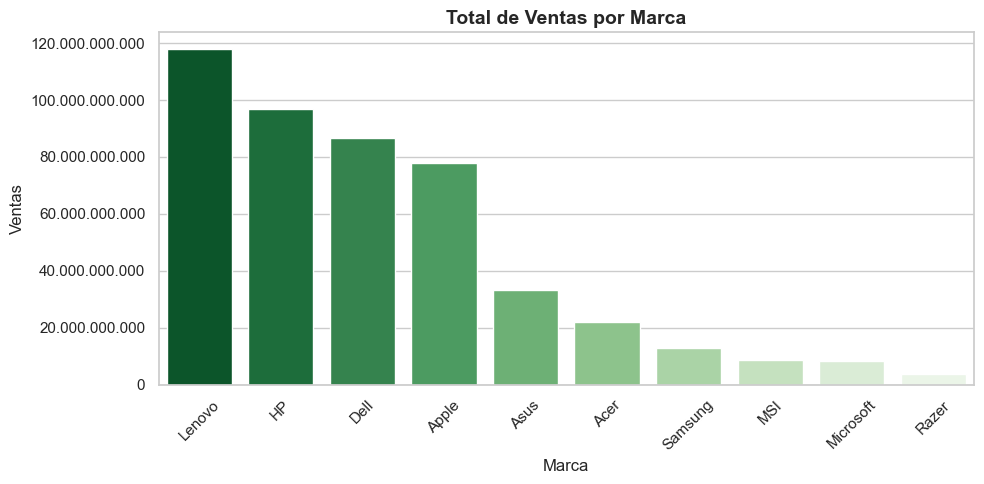

In [72]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=ventas_por_marca,
    x='MarcaProducto',
    y='TotalVentas',
    hue='MarcaProducto',
    palette='Greens_r',
    legend=False
)

ax.set_title('Total de Ventas por Marca', fontsize=14, weight='bold')
ax.set_xlabel('Marca')
ax.set_ylabel('Ventas')

# Rotar etiquetas
plt.xticks(rotation=45)

# Formatear eje Y con separador de miles
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)

plt.tight_layout()
plt.show()


### Top 10 de productos más vendidos

In [73]:
ventas_por_producto = (
    detalle_facturas
    .merge(
        productos[['ProductoID', 'NombreProducto']],
        on='ProductoID',
        how='left'
    )
    .groupby('NombreProducto', as_index=False)
    .agg(
        TotalVentas=('Subtotal', 'sum'),
        CantidadVendida=('Cantidad', 'sum')
    )
    .sort_values('TotalVentas', ascending=False)
)

ventas_por_producto

,NombreProducto,TotalVentas,CantidadVendida
21,Lenovo Legion 5 Pro,4.219920e+10,5861
19,HP Spectre x360,4.017520e+10,7726
22,Lenovo ThinkPad X1 Carbon,3.953520e+10,5814
17,HP Omen 16,3.006600e+10,5011
12,Dell Alienware m15,2.926400e+10,3658
14,Dell Latitude 7420,2.523920e+10,4507
5,Apple MacBook Pro 14,2.496000e+10,3120
23,Lenovo Yoga 7i,2.222880e+10,5052
15,Dell XPS 13,2.172480e+10,4526
6,Apple MacBook Pro 16,2.080320e+10,2167


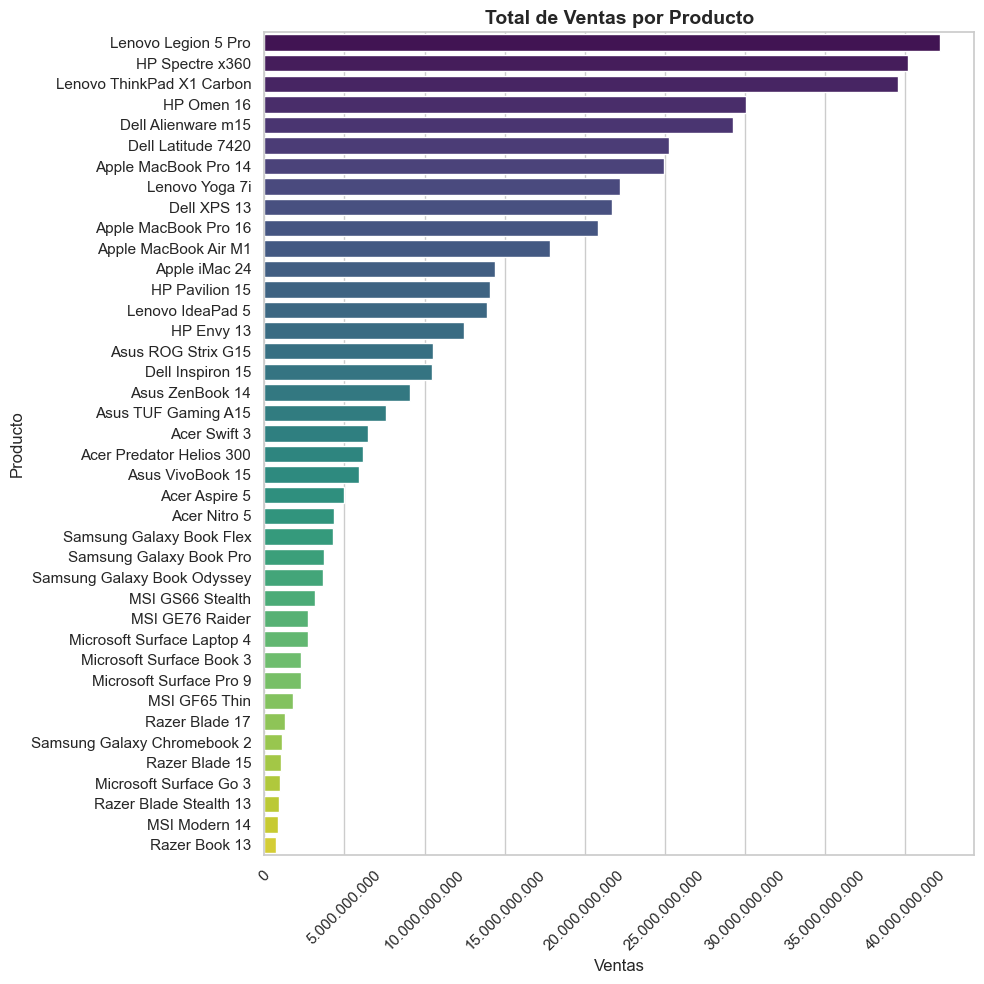

In [74]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,10))

ax = sns.barplot(
    data=ventas_por_producto,
    x='TotalVentas',
    y='NombreProducto',
    hue='NombreProducto',
    palette='viridis',
    legend=False,
    orient='h'
)

ax.set_title('Total de Ventas por Producto', fontsize=14, weight='bold')
ax.set_xlabel('Ventas')
ax.set_ylabel('Producto')

# Rotar etiquetas
plt.xticks(rotation=45)

# Formatear eje X con separador de miles
ax.get_xaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
)

plt.tight_layout()
plt.show()
